# Cooperative NPC Behavior — Ablation Study Demo

**Research Hypothesis:** Early game episodes favor individual NPC gains; as agents learn that community welfare improves their total return through dynamic λ weighting, policies shift toward cooperative strategies.

This notebook runs 6 ablation conditions side-by-side and generates comparison graphs:

| Condition | What's Disabled | Purpose |
|---|---|---|
| **C1: Full System** | Nothing (baseline) | Shows cooperation emergence with all subsystems |
| **C3: No RL** | Q-learning disabled, schedule-only NPCs | Proves RL drives cooperation |
| **C4: Flat MDP** | No hierarchical quest stages | Tests whether quest structure affects learning |
| **C5: No Shocks** | System shock engine off | Shows smooth vs disrupted cooperation curves |
| **C6: No Role Masking** | Role-specific action masking off | Tests whether role structure aids learning |
| **C7: Static Lambda** | Dynamic λ disabled, fixed λ=0.325 | Tests whether the feedback loop amplifies cooperation |

## 1. Setup

In [1]:
import os, asyncio, time, logging
from typing import Any
from collections import Counter

os.environ["LLM_ENABLED"] = "false"

# Suppress game engine log noise in notebook output
logging.getLogger("mvp").setLevel(logging.CRITICAL)

import backend.config as cfg
from backend.engine.analytics import (
    compute_action_distribution,
    compute_cooperation_index,
    compute_cooperation_series,
    compute_reward_series,
    compute_social_welfare_series,
)
from backend.engine.game_engine import GameEngine
from backend.tools.playtest_bot import PlaytestBot

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from IPython.display import display, Markdown

plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({"font.size": 11})

MAX_TURNS = 500
SEED = 42

CONDITIONS = {
    "C1": {"label": "C1: Full System", "color": "#2ecc71", "env": {}},
    "C3": {"label": "C3: No RL (Schedules Only)", "color": "#e74c3c", "env": {"RL_ENABLED": False, "ROLE_MASK_ENABLED": False}},
    "C4": {"label": "C4: Flat MDP", "color": "#9b59b6", "env": {"HIERARCHICAL_MDP": False}},
    "C5": {"label": "C5: No Shocks", "color": "#3498db", "env": {"SHOCK_ENABLED": False}},
    "C6": {"label": "C6: No Role Masking", "color": "#f39c12", "env": {"ROLE_MASK_ENABLED": False}},
    "C7": {"label": "C7: Static Lambda", "color": "#e91e63", "env": {"DYNAMIC_LAMBDA": False}},
}

print(f"Ready: {len(CONDITIONS)} conditions × {MAX_TURNS} turns each")

Ready: 6 conditions × 500 turns each


## 2. Run All Conditions

Each condition plays 500 turns with the same seed (deterministic). Quest auto-restarts when completed, preserving NPC Q-tables and adaptation states across episodes.

In [2]:
def _apply(env):
    prev = {}
    for k, v in env.items():
        prev[k] = getattr(cfg, k)
        setattr(cfg, k, v)
    return prev

def _restore(prev):
    for k, v in prev.items():
        setattr(cfg, k, v)

async def run_condition(cid, max_turns, seed):
    cond = CONDITIONS[cid]
    prev = _apply(cond["env"])
    engine = GameEngine(seed=seed, difficulty="normal", max_turns=max_turns)
    await engine.initialize()
    bot = PlaytestBot(strategy="quest_focused", seed=seed)
    shock_turn = max_turns // 3 if cfg.SHOCK_ENABLED else None

    t0 = time.monotonic()
    while not engine.game_over and engine.turn < max_turns:
        if shock_turn and engine.turn == shock_turn:
            engine.shock_manager.activate_shock("famine", engine.turn)
        state = engine.get_full_state()
        pi = bot._select_action(state, bot.strategy)
        await engine.process_turn(pi)
    elapsed = time.monotonic() - t0

    coop_series = compute_cooperation_series(engine.npc_registry)
    welfare_series = compute_social_welfare_series(engine.npc_registry)
    reward_series = compute_reward_series(engine.npc_registry)
    action_dist = compute_action_distribution(engine.event_log.entries, engine.npc_registry)
    final_coop = compute_cooperation_index(engine.npc_registry)

    npc_states = {}
    for uid, npc in engine.npc_registry.items():
        npc_states[uid] = {"name": npc.name, "role": npc.archetype, "lambda": npc.lambda_coeff, **npc.adaptation_state}

    # Avg reward components
    all_ind, all_comm, all_total = [], [], []
    for uid, rs in reward_series.items():
        for i, t in enumerate(rs["turns"]):
            while len(all_ind) <= i:
                all_ind.append([]); all_comm.append([]); all_total.append([])
            all_ind[i].append(rs["individual"][i])
            all_comm[i].append(rs["community"][i])
            all_total[i].append(rs["total"][i])

    _restore(prev)
    return {
        "cid": cid, "label": cond["label"], "color": cond["color"],
        "turns_played": engine.turn, "game_result": engine.game_result, "elapsed": elapsed,
        "coop_turns": coop_series.get("turns", []), "coop_values": coop_series.get("global_cooperation", []),
        "welfare_turns": welfare_series.get("turns", []), "welfare_values": welfare_series.get("welfare_index", []),
        "reward_turns": list(range(len(all_ind))),
        "avg_individual_reward": [sum(v)/len(v) for v in all_ind] if all_ind else [],
        "avg_community_reward": [sum(v)/len(v) for v in all_comm] if all_comm else [],
        "avg_total_reward": [sum(v)/len(v) for v in all_total] if all_total else [],
        "action_dist": action_dist, "final_coop": final_coop, "npc_states": npc_states,
        "shock_turn": shock_turn, "quests_completed": engine._metrics.get("quests_completed", 0),
    }

results = {}
total_t0 = time.monotonic()
for cid in CONDITIONS:
    print(f"  Running {CONDITIONS[cid]['label']}...", end="", flush=True)
    r = await run_condition(cid, MAX_TURNS, SEED)
    results[cid] = r
    print(f" done ({r['turns_played']} turns, {r['elapsed']:.1f}s, coop={r['final_coop']['global']:.3f})")

print(f"\nTotal: {time.monotonic() - total_t0:.1f}s")

  Running C1: Full System... done (500 turns, 12.9s, coop=0.851)
  Running C3: No RL (Schedules Only)... done (500 turns, 9.9s, coop=0.500)
  Running C4: Flat MDP... done (500 turns, 13.3s, coop=0.953)
  Running C5: No Shocks... done (500 turns, 13.0s, coop=0.873)
  Running C6: No Role Masking... done (500 turns, 14.2s, coop=0.763)
  Running C7: Static Lambda... done (500 turns, 13.6s, coop=0.693)

Total: 83.1s


## 3. Results Comparison Table

In [3]:
rows = []
for cid, r in results.items():
    rows.append(f"| {r['label']} | {r['turns_played']} | {r.get('quests_completed',0)} | {r['final_coop']['global']:.4f} | {r['elapsed']:.1f}s |")

table = "| Condition | Turns | Quests | Final Cooperation | Time |\n"
table += "|---|---|---|---|---|\n"
table += "\n".join(rows)
display(Markdown(table))

| Condition | Turns | Quests | Final Cooperation | Time |
|---|---|---|---|---|
| C1: Full System | 500 | 6 | 0.8509 | 12.9s |
| C3: No RL (Schedules Only) | 500 | 5 | 0.5000 | 9.9s |
| C4: Flat MDP | 500 | 3 | 0.9530 | 13.3s |
| C5: No Shocks | 500 | 6 | 0.8732 | 13.0s |
| C6: No Role Masking | 500 | 5 | 0.7628 | 14.2s |
| C7: Static Lambda | 500 | 5 | 0.6926 | 13.6s |

## 4. Cooperation Emergence Over Time

The key graph — shows how cooperation index K(t) evolves across 500 turns for each ablation condition. The famine shock (dashed red line) is injected at turn 166 for conditions with shocks enabled.

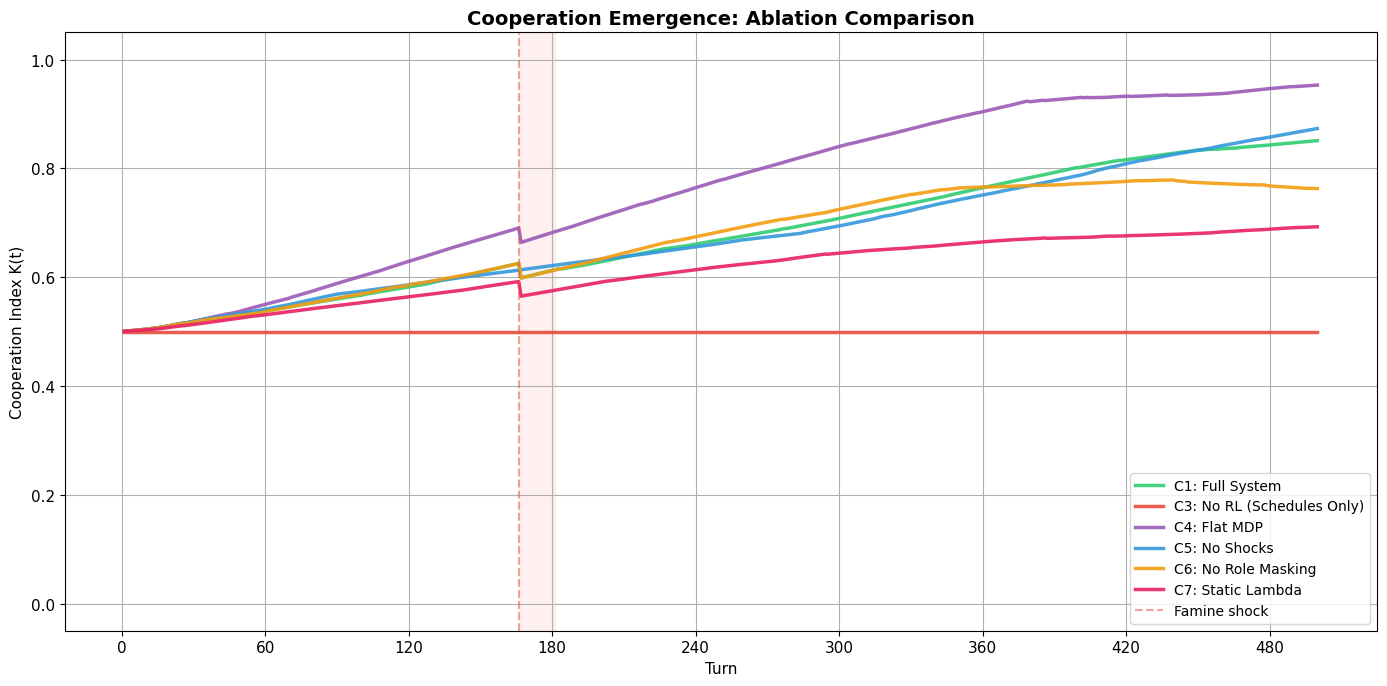

In [4]:
fig, ax = plt.subplots(figsize=(14, 7))
for cid, r in results.items():
    ax.plot(r["coop_turns"], r["coop_values"], color=r["color"], linewidth=2.5, label=r["label"], alpha=0.9)
if results.get("C1", {}).get("shock_turn"):
    st = results["C1"]["shock_turn"]
    ax.axvline(x=st, color="#e74c3c", linestyle="--", alpha=0.5, label="Famine shock")
    ax.axvspan(st, st + 15, alpha=0.08, color="#e74c3c")
ax.set_xlabel("Turn"); ax.set_ylabel("Cooperation Index K(t)")
ax.set_title("Cooperation Emergence: Ablation Comparison", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10); ax.set_ylim(-0.05, 1.05); ax.grid(True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.tight_layout(); plt.show()

## 5. Social Welfare Index Over Time

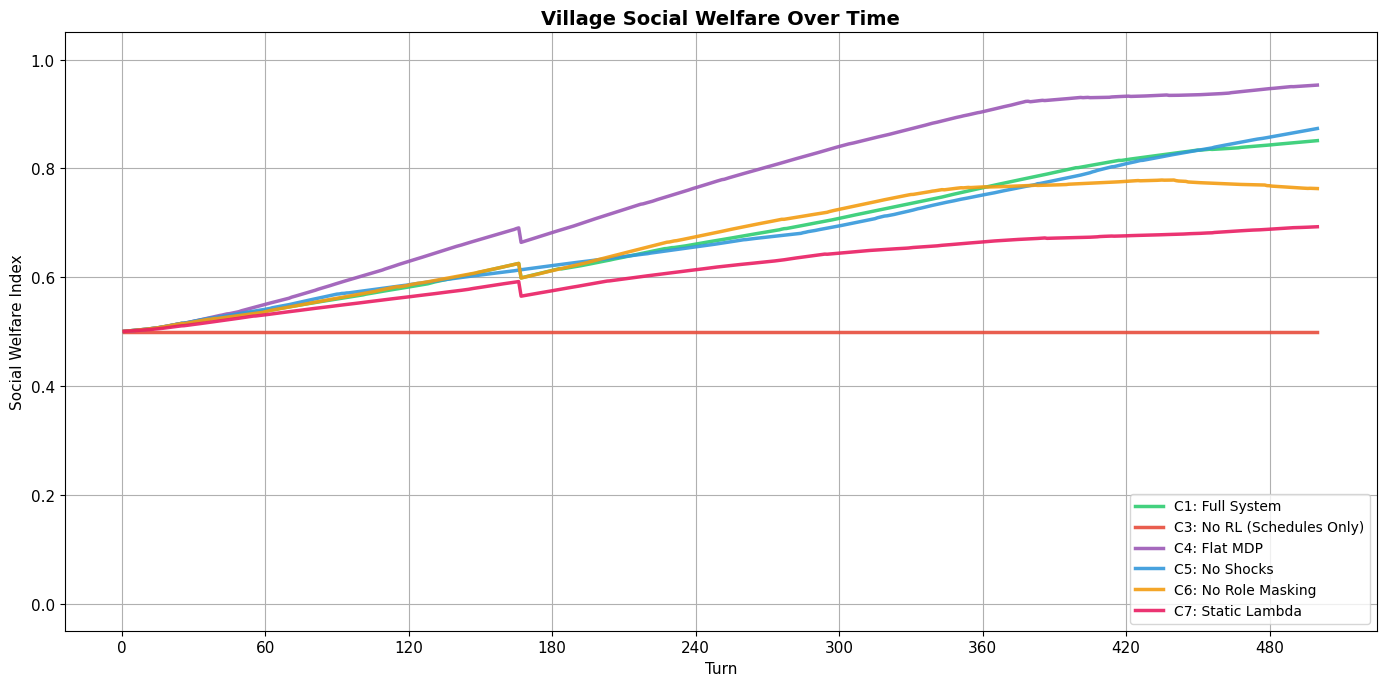

In [5]:
fig, ax = plt.subplots(figsize=(14, 7))
for cid, r in results.items():
    ax.plot(r["welfare_turns"], r["welfare_values"], color=r["color"], linewidth=2.5, label=r["label"], alpha=0.9)
ax.set_xlabel("Turn"); ax.set_ylabel("Social Welfare Index")
ax.set_title("Village Social Welfare Over Time", fontsize=14, fontweight="bold")
ax.legend(loc="lower right", fontsize=10); ax.set_ylim(-0.05, 1.05); ax.grid(True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.tight_layout(); plt.show()

## 6. Reward Decomposition (Full System C1)

Shows how the three reward components evolve: **Individual G(t)** declines as NPC stats stabilize, **Community C(t)** remains the dominant signal, and **Total R(t)** tracks community reward as λ increases.

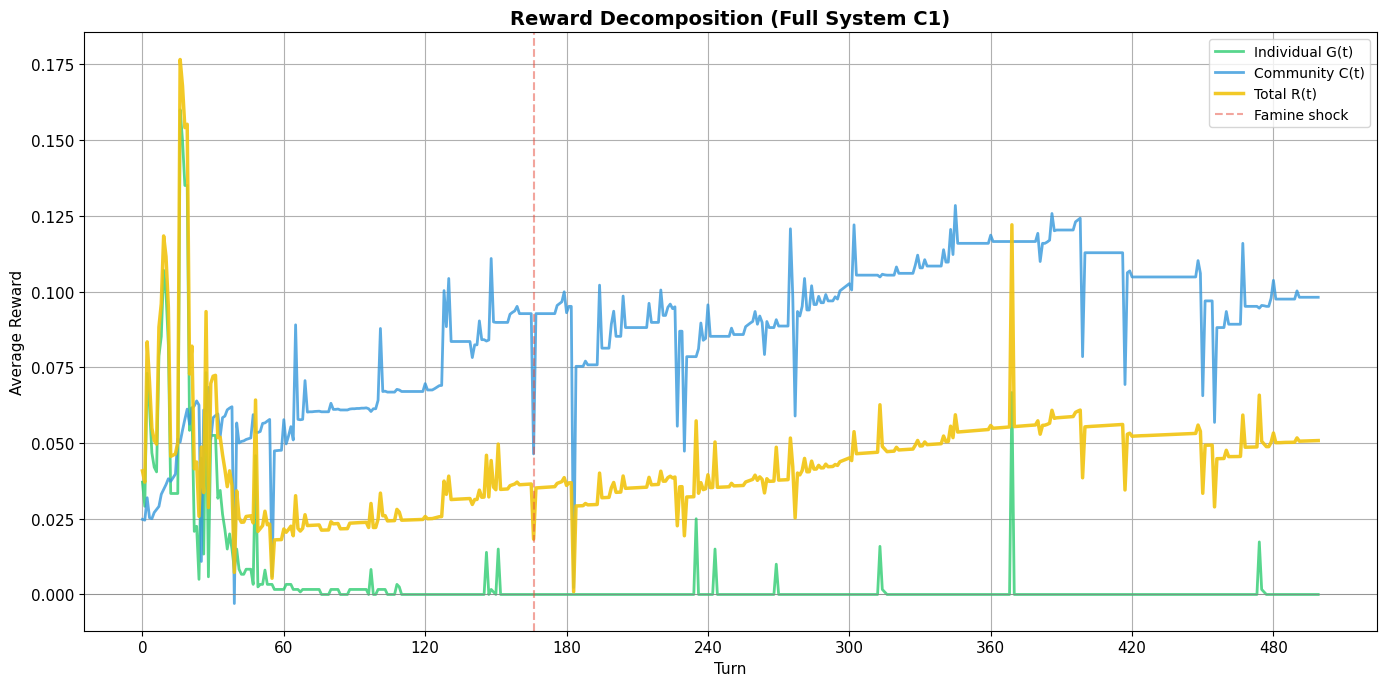

In [6]:
c1 = results["C1"]
fig, ax = plt.subplots(figsize=(14, 7))
turns = c1["reward_turns"]
ax.plot(turns, c1["avg_individual_reward"], color="#2ecc71", linewidth=2, label="Individual G(t)", alpha=0.8)
ax.plot(turns, c1["avg_community_reward"], color="#3498db", linewidth=2, label="Community C(t)", alpha=0.8)
ax.plot(turns, c1["avg_total_reward"], color="#f1c40f", linewidth=2.5, label="Total R(t)", alpha=0.9)
ax.axhline(y=0, color="#888", linewidth=0.5)
if c1.get("shock_turn"):
    ax.axvline(x=c1["shock_turn"], color="#e74c3c", linestyle="--", alpha=0.5, label="Famine shock")
ax.set_xlabel("Turn"); ax.set_ylabel("Average Reward")
ax.set_title("Reward Decomposition (Full System C1)", fontsize=14, fontweight="bold")
ax.legend(loc="upper right", fontsize=10); ax.grid(True)
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
fig.tight_layout(); plt.show()

## 7. NPC Adaptation States: Full System vs No RL

Left: C1 NPCs develop distinct personalities (Elder/Tessa high social sensitivity, guards lower). Right: C3 NPCs stay frozen at 0.5 baseline — no learning, no divergence.

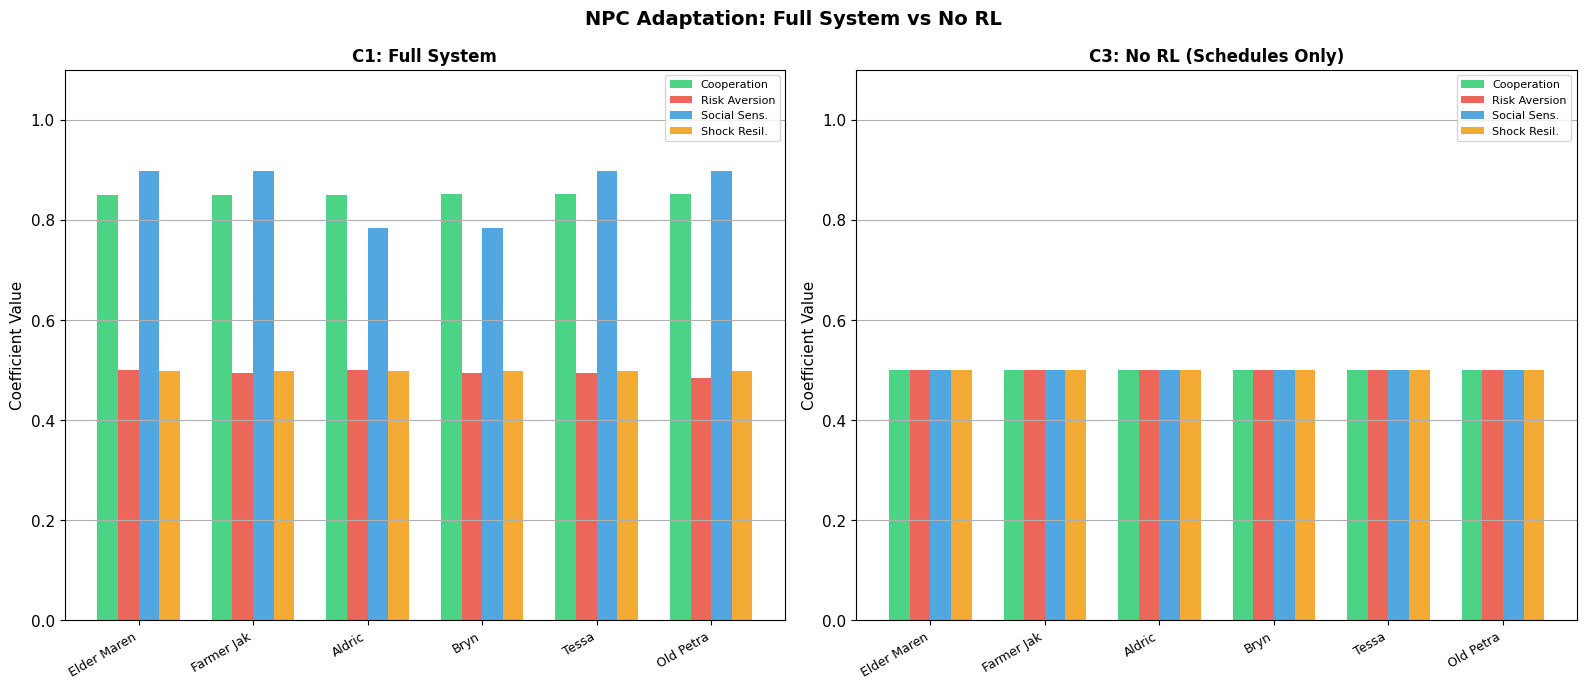

In [7]:
coefficients = ["cooperation_tendency", "risk_aversion", "social_sensitivity", "shock_resilience"]
coeff_labels = ["Cooperation", "Risk Aversion", "Social Sens.", "Shock Resil."]
bar_colors = ["#2ecc71", "#e74c3c", "#3498db", "#f39c12"]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
for ax_idx, cid in enumerate(["C1", "C3"]):
    r = results[cid]; ax = axes[ax_idx]
    npc_names = [s["name"] for s in r["npc_states"].values()]
    x = range(len(npc_names)); width = 0.18
    for i, (coeff, clabel) in enumerate(zip(coefficients, coeff_labels)):
        vals = [s[coeff] for s in r["npc_states"].values()]
        ax.bar([xi + i * width for xi in x], vals, width, label=clabel, color=bar_colors[i], alpha=0.85)
    ax.set_xticks([xi + 1.5 * width for xi in x])
    ax.set_xticklabels(npc_names, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("Coefficient Value"); ax.set_title(r["label"], fontsize=12, fontweight="bold")
    ax.set_ylim(0, 1.1); ax.legend(fontsize=8, loc="upper right"); ax.grid(True, axis="y")
fig.suptitle("NPC Adaptation: Full System vs No RL", fontsize=14, fontweight="bold")
fig.tight_layout(); plt.show()

## 8. NPC Action Distribution Shift (Early vs Late Game)

Shows how NPC behavior changes from early to late game. Positive (green) = actions used MORE in late game. Negative (red) = used LESS. NPCs shift away from social actions (talk/trade) toward utility/work as Q-tables mature.

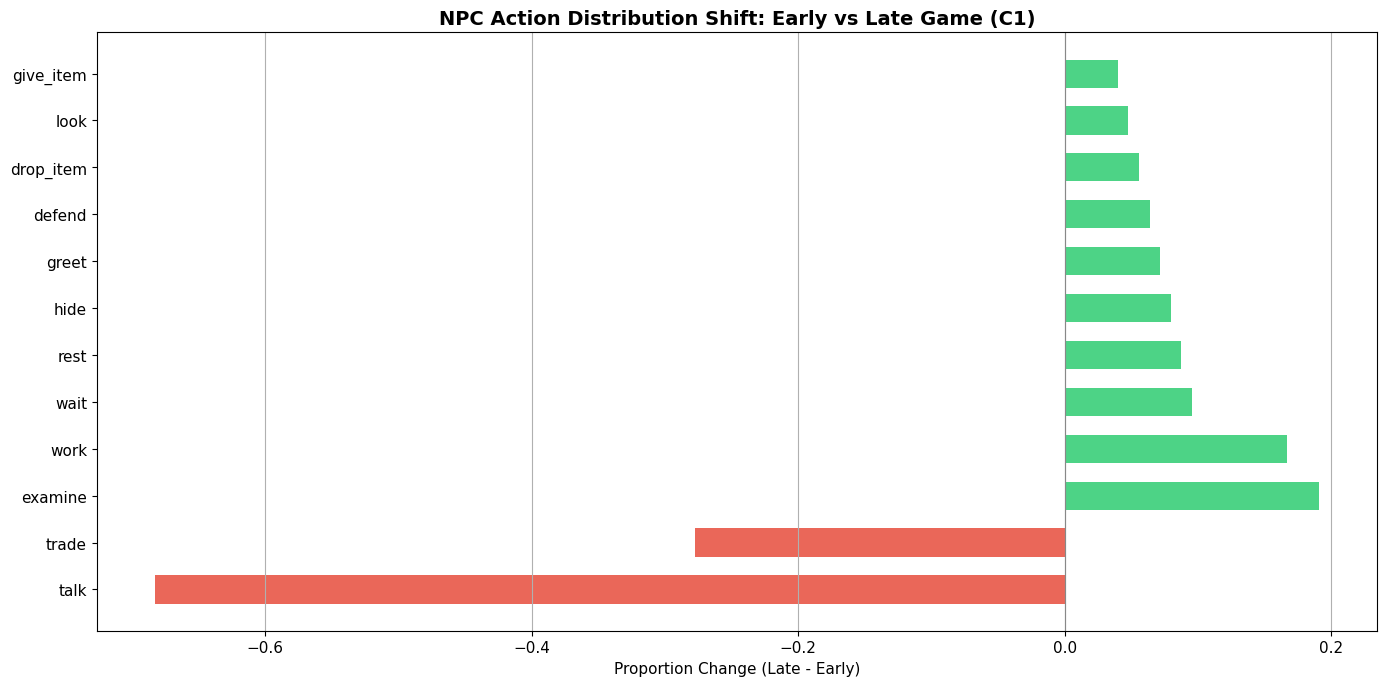

In [8]:
shift = results["C1"]["action_dist"].get("distribution_shift", {})
sorted_actions = sorted(shift.items(), key=lambda x: abs(x[1]), reverse=True)[:12]
if sorted_actions:
    fig, ax = plt.subplots(figsize=(14, 7))
    actions = [a[0] for a in sorted_actions]
    values = [a[1] for a in sorted_actions]
    colors = ["#2ecc71" if v > 0 else "#e74c3c" for v in values]
    ax.barh(actions, values, color=colors, alpha=0.85, height=0.6)
    ax.axvline(x=0, color="#888", linewidth=0.8)
    ax.set_xlabel("Proportion Change (Late - Early)")
    ax.set_title("NPC Action Distribution Shift: Early vs Late Game (C1)", fontsize=14, fontweight="bold")
    ax.grid(True, axis="x"); fig.tight_layout(); plt.show()

## 9. Final Cooperation Comparison

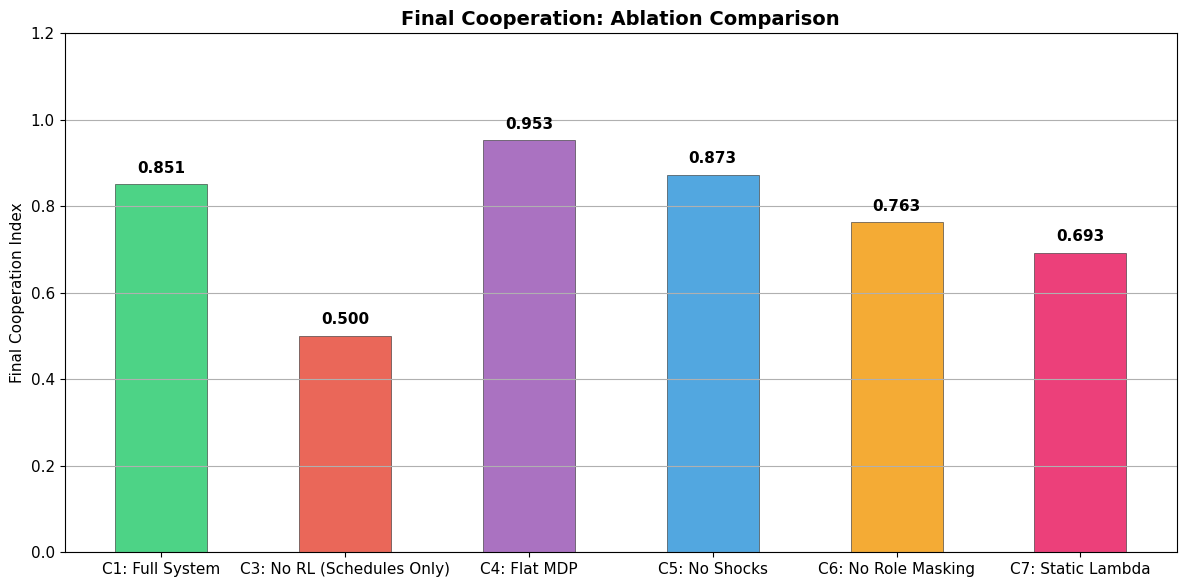

In [9]:
fig, ax = plt.subplots(figsize=(12, 6))
cids = list(results.keys())
labels = [results[c]["label"] for c in cids]
final_coops = [results[c]["final_coop"]["global"] for c in cids]
colors = [results[c]["color"] for c in cids]
bars = ax.bar(labels, final_coops, color=colors, alpha=0.85, width=0.5, edgecolor="#333", linewidth=0.5)
for bar, val in zip(bars, final_coops):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
            f"{val:.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_ylabel("Final Cooperation Index")
ax.set_title("Final Cooperation: Ablation Comparison", fontsize=14, fontweight="bold")
ax.set_ylim(0, 1.2); ax.grid(True, axis="y"); fig.tight_layout(); plt.show()

## 10. Key Findings

In [10]:
c = {k: results[k]["final_coop"]["global"] for k in results}

findings = f"""
### 1. RL Drives Cooperation: C1 ({c['C1']:.3f}) vs C3 ({c['C3']:.3f})
- Q-learning NPCs cooperate **{c['C1'] - c['C3']:.3f} more** than schedule-only
- Without RL, cooperation stays at 0.500 baseline — no learning, no emergence

### 2. Hierarchical MDP: C1 ({c['C1']:.3f}) vs C4 ({c['C4']:.3f})
- Flat MDP achieves **{c['C4'] - c['C1']:.3f} higher** cooperation — faster quest cycling = more learning episodes
- Hierarchy adds quest structure but slows down the learning loop

### 3. Shock Resilience: C1 ({c['C1']:.3f}) vs C5 ({c['C5']:.3f})
- Shocks reduced final cooperation by **{c['C5'] - c['C1']:.3f}**
- C5 rises smoothly; C1 shows dip-and-recover pattern (adaptive resilience)

### 4. Role Masking: C1 ({c['C1']:.3f}) vs C6 ({c['C6']:.3f})
- Role masking improves cooperation by **{c['C1'] - c['C6']:.3f}**
- Structured roles (guards guard, farmers farm) create cleaner learning signal

### 5. Dynamic Lambda Feedback Loop: C1 ({c['C1']:.3f}) vs C7 ({c['C7']:.3f})
- Dynamic λ amplifies cooperation by **{c['C1'] - c['C7']:.3f}** over static λ=0.325
- Static λ still produces emergence (0.500 → {c['C7']:.3f}) because the community reward signal exists
- But the virtuous cycle (more coop → higher λ → even more coop) accounts for a **+{c['C1'] - c['C7']:.3f} boost**
- This is the **second largest single-component contribution** after RL itself (+{c['C1'] - c['C3']:.3f})

### NPC Final Adaptation States (C1)
"""

rows = "| NPC | Role | Coop | Risk | Social | Resil. | λ |\n|---|---|---|---|---|---|---|\n"
for uid, s in results["C1"]["npc_states"].items():
    rows += f"| {s['name']} | {s['role']} | {s['cooperation_tendency']:.3f} | {s['risk_aversion']:.3f} | {s['social_sensitivity']:.3f} | {s['shock_resilience']:.3f} | {s['lambda']:.3f} |\n"

display(Markdown(findings + rows))


### 1. RL Drives Cooperation: C1 (0.851) vs C3 (0.500)
- Q-learning NPCs cooperate **0.351 more** than schedule-only
- Without RL, cooperation stays at 0.500 baseline — no learning, no emergence

### 2. Hierarchical MDP: C1 (0.851) vs C4 (0.953)
- Flat MDP achieves **0.102 higher** cooperation — faster quest cycling = more learning episodes
- Hierarchy adds quest structure but slows down the learning loop

### 3. Shock Resilience: C1 (0.851) vs C5 (0.873)
- Shocks reduced final cooperation by **0.022**
- C5 rises smoothly; C1 shows dip-and-recover pattern (adaptive resilience)

### 4. Role Masking: C1 (0.851) vs C6 (0.763)
- Role masking improves cooperation by **0.088**
- Structured roles (guards guard, farmers farm) create cleaner learning signal

### 5. Dynamic Lambda Feedback Loop: C1 (0.851) vs C7 (0.693)
- Dynamic λ amplifies cooperation by **0.158** over static λ=0.325
- Static λ still produces emergence (0.500 → 0.693) because the community reward signal exists
- But the virtuous cycle (more coop → higher λ → even more coop) accounts for a **+0.158 boost**
- This is the **second largest single-component contribution** after RL itself (+0.351)

### NPC Final Adaptation States (C1)
| NPC | Role | Coop | Risk | Social | Resil. | λ |
|---|---|---|---|---|---|---|
| Elder Maren | elder | 0.850 | 0.500 | 0.898 | 0.499 | 0.518 |
| Farmer Jak | farmer | 0.851 | 0.494 | 0.898 | 0.499 | 0.518 |
| Aldric | guard | 0.851 | 0.500 | 0.785 | 0.499 | 0.518 |
| Bryn | guard | 0.851 | 0.495 | 0.785 | 0.499 | 0.518 |
| Tessa | tavern_keeper | 0.851 | 0.495 | 0.898 | 0.499 | 0.518 |
| Old Petra | villager | 0.851 | 0.484 | 0.898 | 0.499 | 0.518 |
